/kaggle/input/teta-ml-1-2025

In [ ]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches


from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer


In [ ]:
yes_no_colors = ['#FF6E6E', '#7EFD5E']
background_color = '#041744'


fill_color = "#491bbf"
font_style = 'serif'
font_color = '#FDE2FF'

plt.rcParams['axes.facecolor'] = background_color
plt.rcParams['figure.facecolor'] = background_color
plt.rcParams['axes.labelcolor'] = font_color
plt.rcParams['axes.edgecolor'] = font_color
plt.rcParams['font.family'] = font_style
plt.rcParams['text.color'] = font_color
plt.rcParams['xtick.color'] = font_color
plt.rcParams['ytick.color'] = font_color

#### Легкий костыль чтобы заработало

In [ ]:
!kaggle competitions download -c teta-ml-1-2025


In [ ]:
import zipfile

# Путь к загруженному архиву
zip_path = '/content/teta-ml-1-2025.zip'
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall('/content/')


### Итоговый результат

In [ ]:
print("we are goood")

we are goood


Итог: модель CatBoostClassifier результат на обучающей выборке 0.846 на тестовой 0.85

1. **Как обработала данные:** пропусков тут не было, но я решила отскейлить данные, это помогло, результат стал получше, модели стали обучаться получше побыстрее. Изучила корреляцию численных признаков и посмотрела на категоривальные.
2. **Итоговый алгоритм:** лучше всего получился CatBoostRegressor. Почему он? Есть категориальные признаки (host_name, location, location_cluster) и катбуст сам их очень хорошо обрабатывает, поэтому выбран он как итоговый.
3. **Параметры следующие:**


```
model = CatBoostClassifier(
    iterations=1262,
    depth=4,
    border_count=253,
    learning_rate=0.056,
    eval_metric='F1',
    verbose=200,
    task_type="GPU",

)
```
здесь ставила task_type = GPU иначе оно невозможно долго обучалось на таком большом объеме данных.

параметры подбирала с помощью optuna и эти выдали достойный результат на трейне и на тесте.

4. ДЛя всех других вариантов использовала кросс валидацию, тут я сделала просто train_test_split и взяла отдельный кусочек для валидации


### Считали данные

In [ ]:
import pandas as pd

df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [ ]:
print(df_train.shape)
print(df_test.shape)

(786431, 18)
(262144, 17)


In [ ]:
df_train.head(5)

,transaction_time,merch,cat_id,amount,name_1,name_2,gender,street,one_city,us_state,post_code,lat,lon,population_city,jobs,merchant_lat,merchant_lon,target
0,2019-12-27 15:21,fraud_Cormier LLC,health_fitness,148.04,Daniel,Martinez,M,8510 Acevedo Burgs,Kent,OR,97033,45.0838,-120.6649,60,Museum education officer,45.042827,-120.709327,0
1,2019-04-17 23:09,"fraud_Brown, Homenick and Lesch",health_fitness,39.40,Grace,Williams,F,28812 Charles Mill Apt. 628,Plantersville,AL,36758,32.6176,-86.9475,1412,Drilling engineer,31.872266,-87.828247,0
2,2019-09-23 15:02,fraud_Ruecker-Mayert,kids_pets,52.96,Kyle,Park,M,7507 Larry Passage Suite 859,Mount Perry,OH,43760,39.8788,-82.1880,1831,Barrister's clerk,40.010874,-81.841249,0
3,2019-05-13 16:00,"fraud_Mante, Luettgen and Hackett",health_fitness,7.66,Monique,Martin,F,68276 Matthew Springs,Ratcliff,TX,75858,31.3833,-95.0619,43,"Engineer, production",30.888406,-95.141609,0
4,2019-08-18 07:27,fraud_Luettgen PLC,gas_transport,51.59,Christine,Johnson,F,8011 Chapman Tunnel Apt. 568,Blairsden-Graeagle,CA,96103,39.8127,-120.6405,1725,Chartered legal executive (England and Wales),39.376017,-121.311691,0


In [ ]:
df_train.isna().sum()

,0
transaction_time,0
merch,0
cat_id,0
amount,0
name_1,0
name_2,0
gender,0
street,0
one_city,0
us_state,0


In [ ]:
df_test.isna().sum()

,0
transaction_time,0
merch,0
cat_id,0
amount,0
name_1,0
name_2,0
gender,0
street,0
one_city,0
us_state,0


УРА У НАС НЕТ ПРОПУСКОВ УРА ПОБЕДА

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786431 entries, 0 to 786430
Data columns (total 18 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   transaction_time  786431 non-null  object 
 1   merch             786431 non-null  object 
 2   cat_id            786431 non-null  object 
 3   amount            786431 non-null  float64
 4   name_1            786431 non-null  object 
 5   name_2            786431 non-null  object 
 6   gender            786431 non-null  object 
 7   street            786431 non-null  object 
 8   one_city          786431 non-null  object 
 9   us_state          786431 non-null  object 
 10  post_code         786431 non-null  int64  
 11  lat               786431 non-null  float64
 12  lon               786431 non-null  float64
 13  population_city   786431 non-null  int64  
 14  jobs              786431 non-null  object 
 15  merchant_lat      786431 non-null  float64
 16  merchant_lon      78

## Начинаем обработку данных

Давайте сразу взглянем на нашу целевую переменную - оценим баланс классов

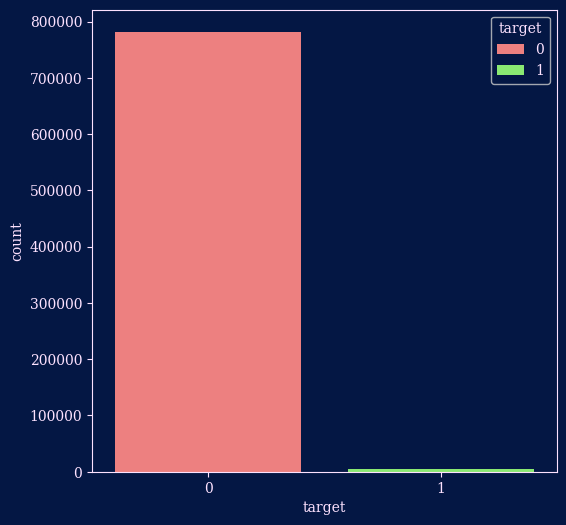

In [ ]:
plt.figure(figsize=(6,6))
sns.countplot(x='target', hue='target', data=df_train, palette=yes_no_colors)
plt.show()

In [ ]:
class_counts = df_train['target'].value_counts(normalize=True) * 100

print("Соотношение классов:")
print(class_counts)
class_weights = {0: 1, 1: class_counts[0] / class_counts[1]}

print("\nВеса классов:")
class_weights


Соотношение классов:
target
0    99.427286
1     0.572714
Name: proportion, dtype: float64

Веса классов:


{0: 1, 1: np.float64(173.6072380106572)}

Несложно заметить, что присутствует выраженный дисбаланс классов

### Обработаем признаки:

In [ ]:
df_train['transaction_time'] = pd.to_datetime(df_train['transaction_time'])
df_test['transaction_time'] = pd.to_datetime(df_test['transaction_time'])

df_train['transaction_month'] = df_train['transaction_time'].dt.month
df_test['transaction_month'] = df_test['transaction_time'].dt.month


df_train['transaction_year'] = df_train['transaction_time'].dt.year
df_test['transaction_year'] = df_test['transaction_time'].dt.year


df_train['transaction_hour'] = df_train['transaction_time'].dt.hour
df_test['transaction_hour'] = df_test['transaction_time'].dt.hour

In [ ]:
df_train.drop('transaction_time', axis=1, inplace=True, errors='ignore')
df_test.drop('transaction_time', axis=1, inplace=True, errors='ignore')

In [ ]:
df_f = df_train[df_train['target'] == 1]

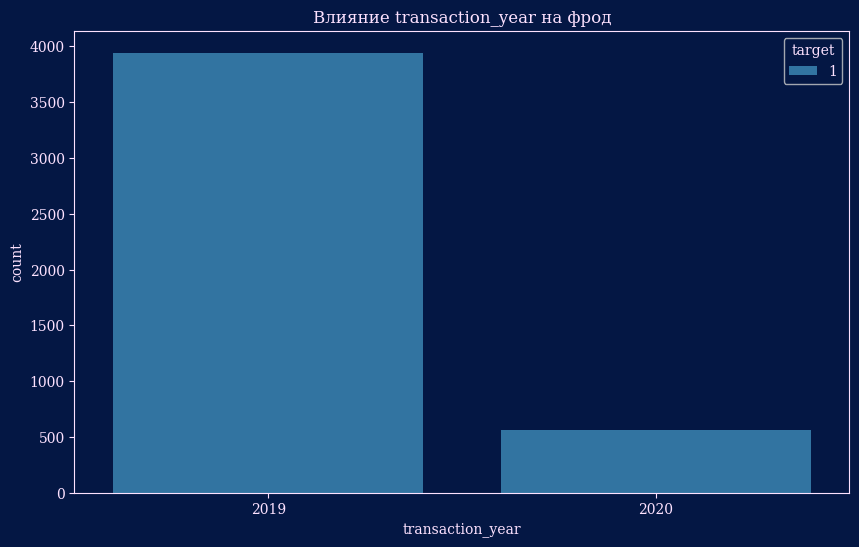

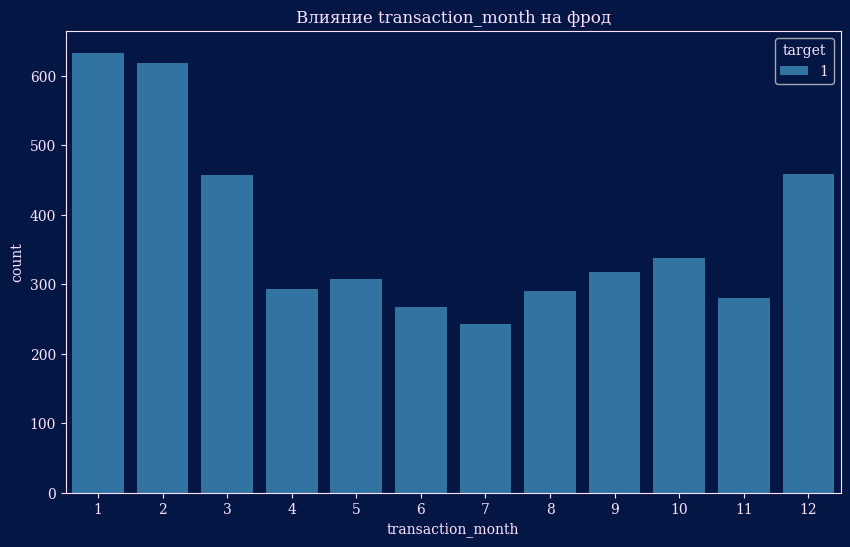

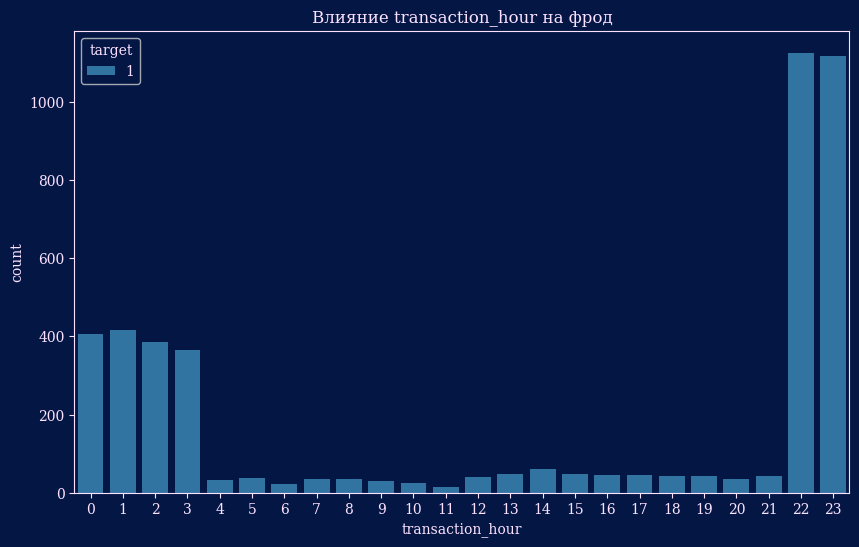

In [ ]:
cols = ['transaction_year', 'transaction_month','transaction_hour']

for col in cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='target', data=df_f)
    plt.title(f'Влияние {col} на фрод')


In [ ]:
df_train['is_time_target'] = np.where(df_train['transaction_hour'].isin([22, 23, 0, 1, 2, 3]), 1, 0)
df_test['is_time_target'] = np.where(df_test['transaction_hour'].isin([22, 23, 0, 1, 2, 3]), 1, 0)

df_train.drop('transaction_hour', axis=1, inplace=True, errors='ignore')
df_test.drop('transaction_hour', axis=1, inplace=True, errors='ignore')

In [ ]:
df_train['is_month_target'] = np.where(df_train['transaction_month'].isin([12, 1, 2,3 ]), 1, 0)
df_test['is_month_target'] = np.where(df_test['transaction_month'].isin([12, 1, 2, 3]), 1, 0)

df_train.drop('transaction_month', axis=1, inplace=True, errors='ignore')
df_test.drop('transaction_month', axis=1, inplace=True, errors='ignore')

In [ ]:
categorical_columns = ['merch', 'cat_id', 'name_1', 'name_2',
                       'gender', 'street', 'one_city', 'us_state', 'jobs']



In [ ]:
categorical_columns = df_train.select_dtypes(include=['object', 'category']).columns

In [ ]:
for i in categorical_columns:
  print(i, len(df_train[i].unique()))

merch 693
cat_id 14
name_1 348
name_2 479
gender 2
street 965
one_city 879
us_state 51
jobs 493


In [ ]:
# своершим ужасную вещь, выбросим колонки где слишком много уникальных значение
cols_drop = ['street', 'one_city', 'name_1', 'name_2']

In [ ]:
df_train.drop(cols_drop, axis=1, inplace=True, errors='ignore')
df_test.drop(cols_drop, axis=1, inplace=True, errors='ignore')

In [ ]:
categorical_columns = ['cat_id', 'gender',]

In [ ]:
numers_columns = df_train.select_dtypes(include=np.number).columns

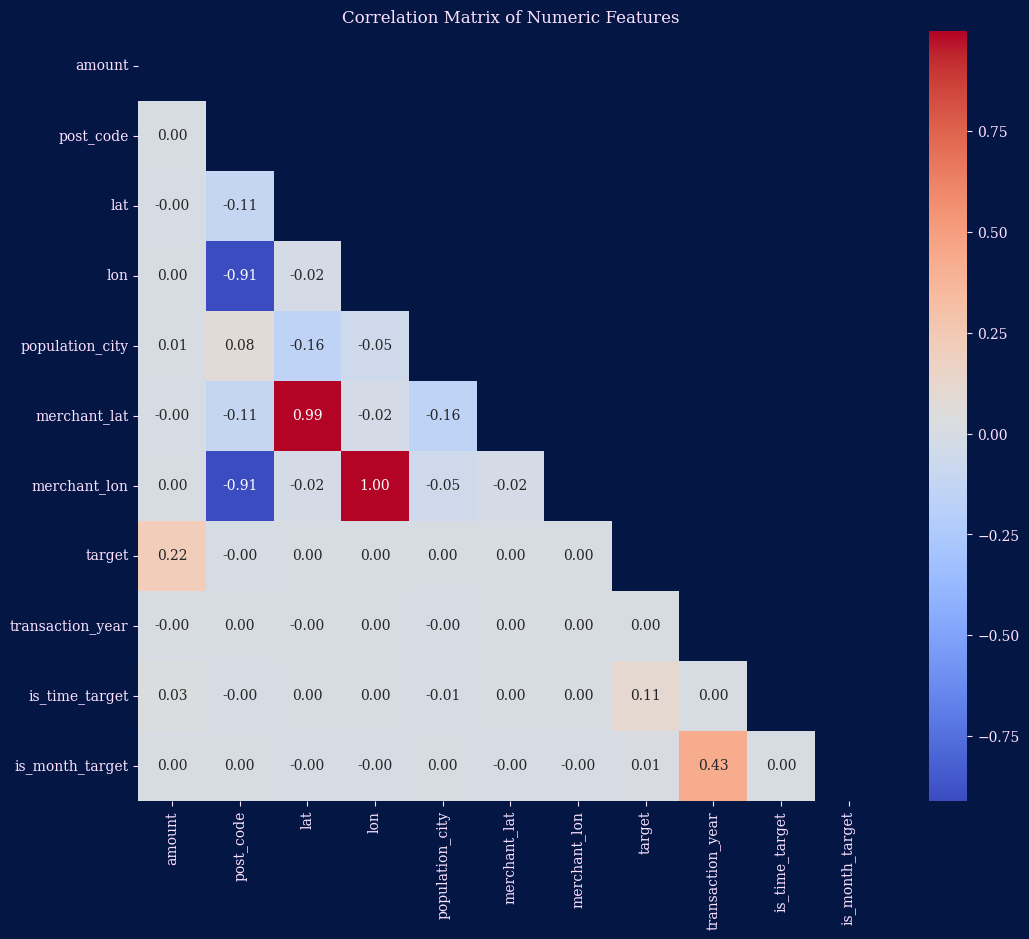

In [ ]:
correlation_matrix = df_train[numers_columns].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", mask = np.triu(correlation_matrix))
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [ ]:
# у нас высокая корреляция между долготой/широтой и долготой/широтой у продавца, поэтому удалим что то
# ну и post_code не особо влияет на таргет
df_train.drop(['lat', 'lon', 'post_code', 'merchant_lat', 'merchant_lon', 'transaction_year'], axis=1, inplace=True, errors='ignore')
df_test.drop(['lat', 'lon', 'post_code', 'merchant_lat', 'merchant_lon', 'transaction_year'], axis=1, inplace=True, errors='ignore')

#### Смотрим на влияния дальше

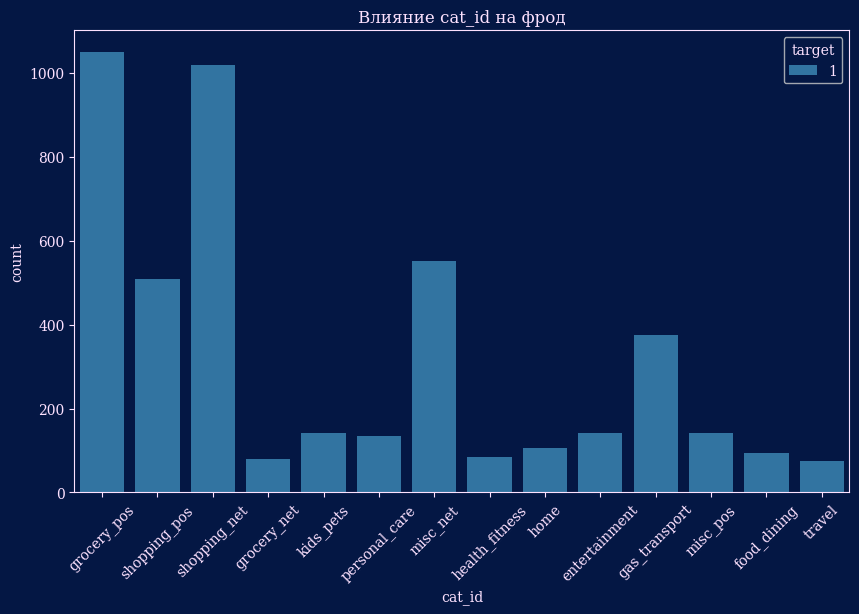

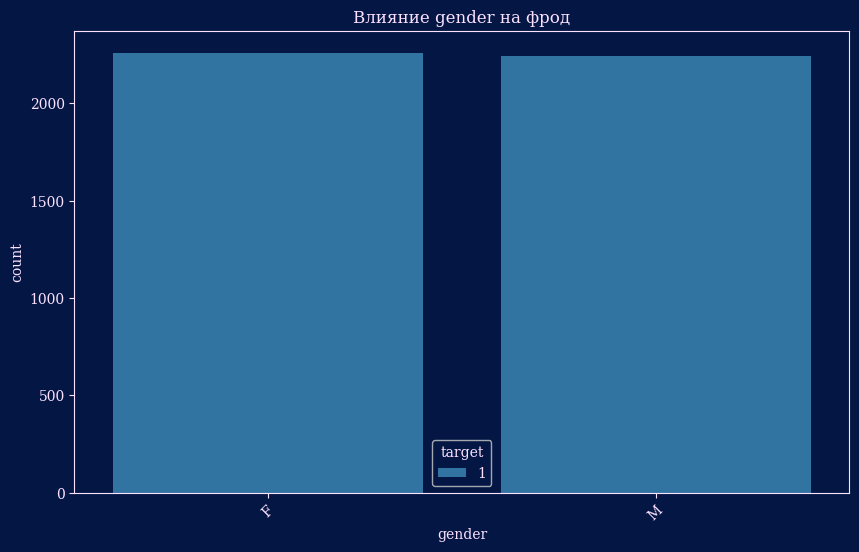

In [ ]:


for column in categorical_columns:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=column, hue='target', data=df_f)
    plt.title(f'Влияние {column} на фрод')
    plt.xticks(rotation= 45)
    plt.show()

In [ ]:
df_train.shape

(786431, 10)

In [ ]:
df_train.isna().sum()

,0
merch,0
cat_id,0
amount,0
gender,0
us_state,0
population_city,0
jobs,0
target,0
is_time_target,0
is_month_target,0


Теперь закодируем признаки: OneHotEncoding или LabelEncoding

In [ ]:
!pip install category-encoders

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.7/85.7 kB 4.5 MB/s eta 0:00:00


In [ ]:
import category_encoders as ce

cat_columns = ['merch', 'us_state','jobs']
target_enc = ce.CatBoostEncoder(cols=cat_columns)

target_enc = target_enc.fit(df_train[cat_columns], df_train['target'])

train_encoded = target_enc.transform(df_train[cat_columns]).add_suffix('_cb')
test_encoded = target_enc.transform(df_test[cat_columns]).add_suffix('_cb')


df_train = df_train.join(train_encoded)
df_test = df_test.join(test_encoded)

df_train.drop(columns=cat_columns, inplace=True)
df_test.drop(columns=cat_columns, inplace=True)

In [ ]:
label_encoder = LabelEncoder()
df_train['gender'] = label_encoder.fit_transform(df_train['gender'])
df_test['gender'] = label_encoder.transform(df_test['gender'])

In [ ]:
encoder = ce.OrdinalEncoder(cols=['cat_id'], return_df=True)

X_train = df_train.drop(columns=['target'])
y_train = df_train['target']

X_train_ = encoder.fit_transform(X_train)

X_test_final = encoder.transform(df_test)

In [ ]:
numerical_columns = X_train_.select_dtypes(include=[np.number]).columns

scaler = MinMaxScaler()
X_train_[numerical_columns] = scaler.fit_transform(X_train_[numerical_columns])
X_test_final[numerical_columns] = scaler.transform(X_test_final[numerical_columns])

In [ ]:
y_train_ = df_train['target']

In [ ]:
X_train_.head()

,cat_id,amount,gender,population_city,is_time_target,is_month_target,merch_cb,us_state_cb,jobs_cb
0,0.000000,0.005369,1.0,0.000013,0.0,1.0,0.430155,0.006056,0.015120
1,0.000000,0.001402,0.0,0.000478,1.0,0.0,0.070194,0.003723,0.006026
2,0.076923,0.001897,1.0,0.000622,0.0,0.0,0.108974,0.005633,0.013400
3,0.000000,0.000243,0.0,0.000007,0.0,0.0,0.036398,0.003257,0.005567
4,0.153846,0.001847,0.0,0.000586,0.0,0.0,0.142263,0.004194,0.011893


In [ ]:
X_test_final.head()

,cat_id,amount,gender,population_city,is_time_target,is_month_target,merch_cb,us_state_cb,jobs_cb
0,1.000000,0.000905,1.0,0.000645,1.0,0.0,0.067172,0.003257,0.005797
1,0.000000,0.003169,1.0,0.001311,0.0,0.0,0.036222,0.005529,0.006274
2,0.307692,0.000364,0.0,0.000029,0.0,1.0,0.131880,0.003257,0.012159
3,0.153846,0.002591,0.0,0.001935,1.0,0.0,0.252788,0.004317,0.006894
4,0.538462,0.007649,0.0,0.049588,1.0,1.0,0.244724,0.003257,0.009748


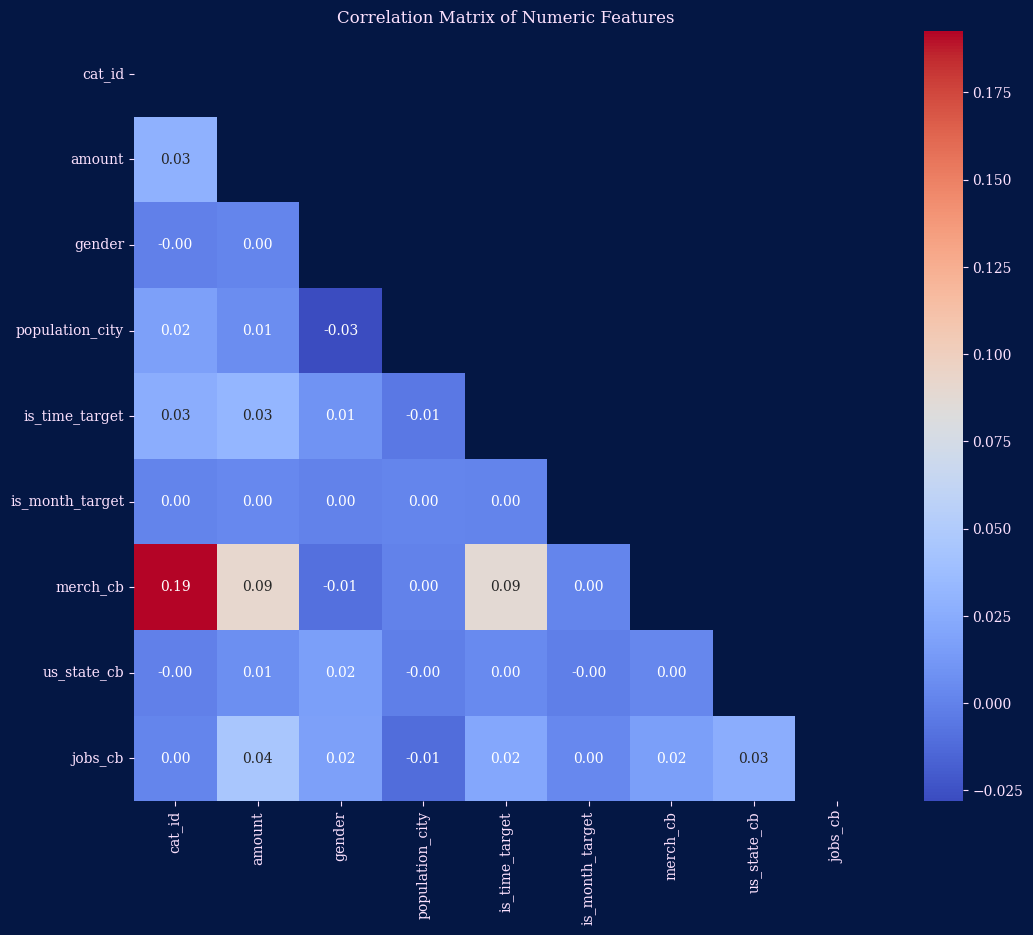

In [ ]:
correlation_matrix = X_train_.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", mask = np.triu(correlation_matrix))
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_train_, y_train_, test_size=0.2, random_state=42, shuffle=True)

Видим, что в целом признаки не сильно коррелируют между собой кроме merch_cb, но корреляция 0.2 еще терпимо

## Обучаем модели

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, classification_report
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score

### Решающее дерево

#### Модель 1: дерево решений. Тестовый первый вариант чтобы разобраться с системой

Почему дерево решений? Подходит для задач классификации, достаточно простое само по себе, в целом не обязательно обрабатывать категориальыне признаки (но это на будущее уже сделано)

выбран DecisionTreeClassifier из sklearn, тк он хорошо интерпретируется

Валидируем кросс валидацией, тк хорошо показывает среднюю эффективность алгоритма

In [ ]:
desicion_tree = DecisionTreeClassifier(random_state=42)
desicion_tree.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
y_pred_dt = desicion_tree.predict(X_test)

In [ ]:

f1_dt = f1_score(y_test, y_pred_dt)
print(f"F1 для дерева решений: {f1_dt}")
print(classification_report(y_test, y_pred_dt))


F1 для дерева решений: 0.7111350188273265
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156378
           1       0.70      0.73      0.71       909

    accuracy                           1.00    157287
   macro avg       0.85      0.86      0.85    157287
weighted avg       1.00      1.00      1.00    157287



In [ ]:
cv_dt = cross_val_score(desicion_tree, X_train, y_train, cv=5, scoring='f1')
print(f"кросс-валидация F1 для дерева решений: {cv_dt.mean()}")

кросс-валидация F1 для дерева решений: 0.7138031939742164


#### Дерево решений, но уже с подбором параметров

Обоснование есть в предыдущем пункте. Теперь опишем что можно улучшить здесь:

- ограничить глубину
- поработаем с дисбалансом классов

на данный момент выберем просто какие то параметры и посмотрим на скор

In [ ]:
desicion_tree_1 = DecisionTreeClassifier(random_state=42, class_weight='balanced')
desicion_tree_1.fit(X_train, y_train)


y_pred_dt = desicion_tree_1.predict(X_test)



f1_dt = f1_score(y_test, y_pred_dt)
print(f"F1 для дерева решений: {f1_dt}")
print(classification_report(y_test, y_pred_dt))

F1 для дерева решений: 0.7249154453213078
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156378
           1       0.74      0.71      0.72       909

    accuracy                           1.00    157287
   macro avg       0.87      0.85      0.86    157287
weighted avg       1.00      1.00      1.00    157287



In [ ]:
cv_dt = cross_val_score(desicion_tree_1, X_train, y_train, cv=5, scoring='f1')
print(f"кросс-валидация F1 для дерева решений: {cv_dt.mean()}")

кросс-валидация F1 для дерева решений: 0.7342386813354744


Идея сбалансировать классы в целом сработала, скор на обучающей выборке стал лучше, но валидация не показала сильно большоги улучшения.

#### Попробуем добавить энтропию

In [ ]:
decision_tree_entropy = DecisionTreeClassifier(criterion='entropy',random_state=42, class_weight='balanced')
decision_tree_entropy.fit(X_train, y_train)


y_pred_dt = decision_tree_entropy.predict(X_test)



f1_dt = f1_score(y_test, y_pred_dt)
print(f"F1 для дерева решений: {f1_dt}")
print(classification_report(y_test, y_pred_dt))

F1 для дерева решений: 0.7325645249862712
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156378
           1       0.73      0.73      0.73       909

    accuracy                           1.00    157287
   macro avg       0.86      0.87      0.87    157287
weighted avg       1.00      1.00      1.00    157287



In [ ]:
cv_dt = cross_val_score(decision_tree_entropy, X_train, y_train, cv=5, scoring='f1')
print(f"кросс-валидация для дерева решений: {cv_dt.mean()}")

кросс-валидация для дерева решений: 0.7343183763772406


Неплохо, изменение критерия разделения помогло нам

### Случайный Лес - улучшение решающего дерева

In [ ]:
from sklearn.ensemble import RandomForestClassifier

Случайный лес - ансамблевая модель, использует несколько деревьев.

- Засчет классификации несколькими деревьями повышается точность
- Лучше выявляет слоэные зависимости
- решает некоторые проблемы переобучения

Использовали кросс валидацию, для исследования стабильности модели

- n_estimators = число деревьев
- class_weight= 'balnced' выяснили по прошлой модели, что в случае дисбаланса лучше обучается так

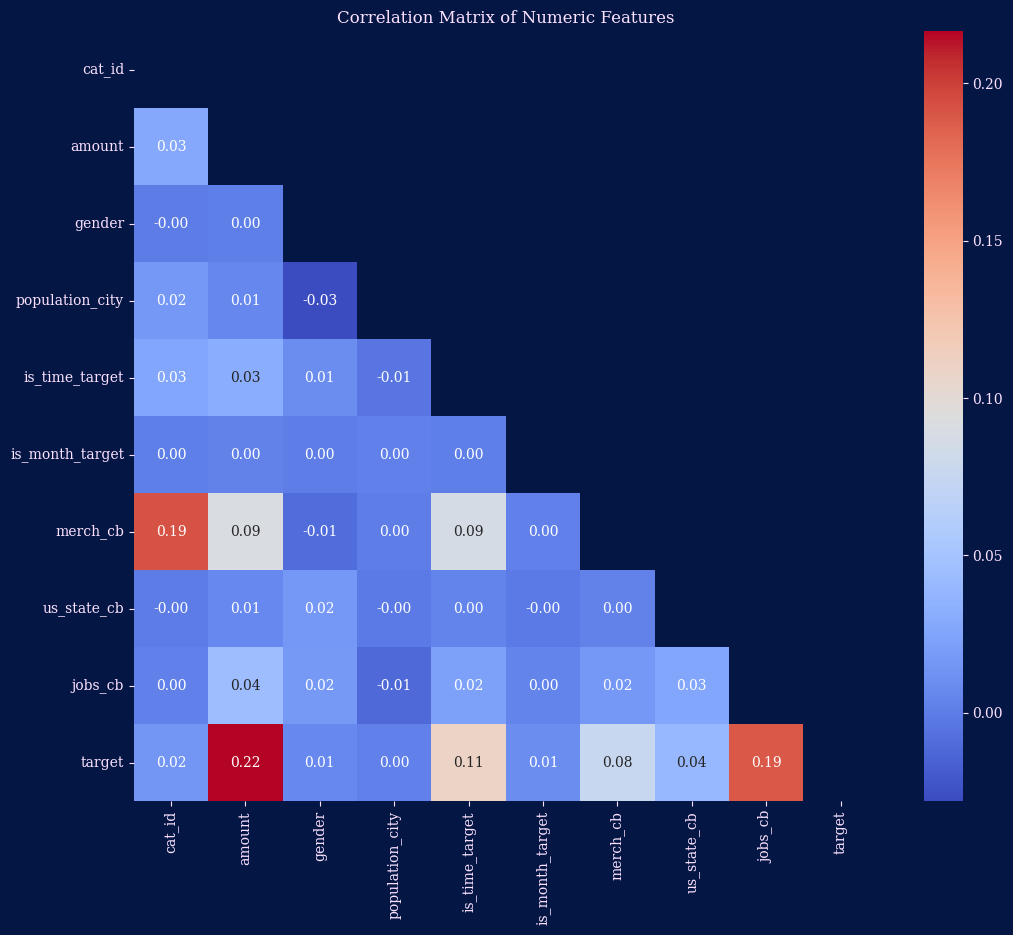

In [ ]:
X_train_copy = X_train_.copy()
X_train_copy['target'] = y_train_
correlation_matrix = X_train_copy.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True,
            cmap='coolwarm', fmt=".2f", mask = np.triu(correlation_matrix))
plt.title('Correlation Matrix of Numeric Features')
plt.show()


In [ ]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42, shuffle=True)

In [ ]:
random_forest = RandomForestClassifier(n_estimators = 200,
                                       min_samples_leaf= 5,
                                       min_samples_split= 5,
                                       max_depth = 26,
                                       criterion = 'entropy',
                                       max_features = 'sqrt',
                                       class_weight='balanced',
                                       n_jobs=-1 ,
                                       random_state= 42)

random_forest.fit(X_train, y_train)

y_pred_rf = random_forest.predict(X_test)

f1_rf = f1_score(y_test, y_pred_rf)
print(f"F1 для дерева решений: {f1_rf}")
print(classification_report(y_test, y_pred_rf))

F1 для дерева решений: 0.7816216216216216
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156378
           1       0.77      0.80      0.78       909

    accuracy                           1.00    157287
   macro avg       0.88      0.90      0.89    157287
weighted avg       1.00      1.00      1.00    157287



Кросс валидация у меня почему то очень сильно отлетала (интернет) поэтому просто валидационный сет(

In [ ]:
y_pred_val = random_forest.predict(X_val)
f1_val = f1_score(y_val, y_pred_val)
print(f"F1 на валидационном сете: {f1_val}")

F1 на валидационном сете: 0.7911714770797963


Какое счастье, ичпользование случайного леса сделало нашу жизнь лучше да еще и кросс валидация более стабильна, прекрасно прекрасно, теперь займемся подбором ЛУЧШИХ параметров


p.s пыталась через grid search, но у меня какие то беды с интернетом были поэтому ручками что то подобралось

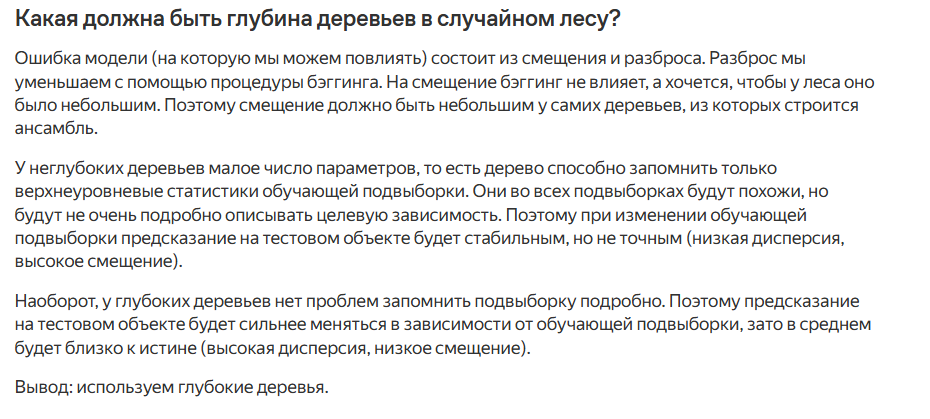

Выдержка из хэндбука яндекса, поэтому вот тут вот я и поставила немаленькую глубину.

### CatBoost

In [ ]:
!pip uninstall catboost

Found existing installation: catboost 1.2.7
Uninstalling catboost-1.2.7:
  Would remove:
    /usr/local/etc/jupyter/nbconfig/notebook.d/catboost-widget.json
    /usr/local/lib/python3.11/dist-packages/catboost-1.2.7.dist-info/*
    /usr/local/lib/python3.11/dist-packages/catboost/*
    /usr/local/share/jupyter/labextensions/catboost-widget/package.json
    /usr/local/share/jupyter/labextensions/catboost-widget/static/138.1b18795f1631648f3df1.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/479.d43617224b25ecf15b1d.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/479.d43617224b25ecf15b1d.js.LICENSE.txt
    /usr/local/share/jupyter/labextensions/catboost-widget/static/486.bafd26b008c3405f7750.js
    /usr/local/share/jupyter/labextensions/catboost-widget/static/486.bafd26b008c3405f7750.js.LICENSE.txt
    /usr/local/share/jupyter/labextensions/catboost-widget/static/755.297bcad6e07632169fc2.js
    /usr/local/share/jupyter/labextensions/catboost-widge

In [ ]:
!pip install catboost==1.2.6

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 4.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 5.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 82.4 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
!pip install catboost -U numpy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 98.7/98.7 MB 8.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.3/18.3 MB 76.9 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2


In [ ]:
from catboost import CatBoostClassifier, Pool

тк испльзуем катбуст то тут от греха подельше лучше еще разочек считать датасет

А еще он очень криво ставился но поставился

In [ ]:
df_train = pd.read_csv('train.csv')
df_test = pd.read_csv('test.csv')

In [ ]:
df_test.shape

(262144, 17)

In [ ]:
df_train['transaction_time'] = pd.to_datetime(df_train['transaction_time'])
df_test['transaction_time'] = pd.to_datetime(df_test['transaction_time'])

df_train['transaction_month'] = df_train['transaction_time'].dt.month
df_test['transaction_month'] = df_test['transaction_time'].dt.month


df_train['transaction_year'] = df_train['transaction_time'].dt.year
df_test['transaction_year'] = df_test['transaction_time'].dt.year


df_train['transaction_hour'] = df_train['transaction_time'].dt.hour
df_test['transaction_hour'] = df_test['transaction_time'].dt.hour

In [ ]:
cols_drop = ['address', 'street', 'one_city', 'name_1', 'name_2', 'lat', 'lon', 'post_code', 'merchant_lat', 'merchant_lon', 'transaction_time', 'transaction_year']

In [ ]:
df_train.drop(cols_drop, axis=1, inplace=True, errors='ignore')
df_test.drop(cols_drop, axis=1, inplace=True, errors='ignore')

In [ ]:
numerical_columns = df_test.select_dtypes(include=[np.number]).columns

scaler = MinMaxScaler()
df_train[numerical_columns] = scaler.fit_transform(df_train[numerical_columns])
df_test[numerical_columns] = scaler.transform(df_test[numerical_columns])

In [ ]:
df_train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 786431 entries, 0 to 786430
Data columns (total 10 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   merch              786431 non-null  object 
 1   cat_id             786431 non-null  object 
 2   amount             786431 non-null  float64
 3   gender             786431 non-null  object 
 4   us_state           786431 non-null  object 
 5   population_city    786431 non-null  float64
 6   jobs               786431 non-null  object 
 7   target             786431 non-null  int64  
 8   transaction_month  786431 non-null  float64
 9   transaction_hour   786431 non-null  float64
dtypes: float64(4), int64(1), object(5)
memory usage: 60.0+ MB


In [ ]:
df_train.shape

(786431, 10)

In [ ]:
df_test.shape

(262144, 9)

In [ ]:
df_train.columns

Index(['merch', 'cat_id', 'amount', 'gender', 'us_state', 'population_city',
       'jobs', 'target', 'transaction_month', 'transaction_hour'],
      dtype='object')

In [ ]:
X_train = df_train.drop(columns=['target'])
y_train = df_train['target']

X_train, X_test, y_train, y_test = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

cats = ['merch', 'cat_id', 'gender', 'us_state', 'jobs']


X_train_cat = X_train[cats]
X_train_num = X_train.drop(columns=cats)

X_test_cat = X_test[cats]
X_test_num = X_test.drop(columns=cats)

train_data = Pool(data=X_train, label=y_train, cat_features=cats)

test_data = Pool(data=X_test, cat_features=cats)


trai_data_search = Pool(data=X_train, cat_features=cats)
y_search = y_train.copy()


In [ ]:
train_data.shape

(629144, 9)

вот щас я месяц не убирала

In [ ]:
model.fit(train_data)

0:	learn: 0.4484445	total: 90.8ms	remaining: 1m 54s
200:	learn: 0.7971983	total: 10.1s	remaining: 53.2s
400:	learn: 0.8209838	total: 20.9s	remaining: 44.9s
600:	learn: 0.8332304	total: 29.6s	remaining: 32.5s
800:	learn: 0.8410525	total: 38.4s	remaining: 22.1s
1000:	learn: 0.8476658	total: 45.9s	remaining: 12s
1200:	learn: 0.8531533	total: 54.6s	remaining: 2.77s
1261:	learn: 0.8536810	total: 56.8s	remaining: 0us


In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 383.6/383.6 kB 12.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 231.8/231.8 kB 21.5 MB/s eta 0:00:00


In [ ]:
def objective(trial):
    param = {
        'iterations': trial.suggest_int('iterations', 1000, 2000),
        'depth': trial.suggest_int('depth', 2, 7),
        'learning_rate': trial.suggest_float('learning_rate', 1e-2, 0.1),
        'border_count': trial.suggest_int('border_count', 150, 255),
        'eval_metric': 'F1',
        'l2_leaf_reg': trial.suggest_int('l2_leaf_reg', 1, 5),
        'verbose': 200 ,
        'task_type': 'GPU',
    }

    model = CatBoostClassifier(**param)
    model.fit(train_data, verbose=200)
    y_pred = model.predict(test_data)
    f1 = f1_score(y_test, y_pred)

    return f1


In [ ]:
import optuna
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=3)


[I 2025-03-26 19:50:55,474] A new study created in memory with name: no-name-011480c6-5633-4312-bf5c-ef1d4b92db70


0:	learn: 0.4484445	total: 101ms	remaining: 2m 4s
200:	learn: 0.8102823	total: 11.4s	remaining: 58.1s
400:	learn: 0.8330241	total: 21.7s	remaining: 44.8s
600:	learn: 0.8492687	total: 32.2s	remaining: 33.6s
800:	learn: 0.8573186	total: 42.3s	remaining: 22.6s
1000:	learn: 0.8642506	total: 51.9s	remaining: 11.8s
1200:	learn: 0.8716774	total: 1m 1s	remaining: 1.44s
1228:	learn: 0.8724607	total: 1m 3s	remaining: 0us


[I 2025-03-26 19:52:08,441] Trial 0 finished with value: 0.8585017835909632 and parameters: {'iterations': 1229, 'depth': 5, 'learning_rate': 0.052730174691317536, 'border_count': 163, 'l2_leaf_reg': 3}. Best is trial 0 with value: 0.8585017835909632.


0:	learn: 0.4484445	total: 43.7ms	remaining: 1m 15s
200:	learn: 0.7658879	total: 8.34s	remaining: 1m 3s
400:	learn: 0.7962282	total: 15.5s	remaining: 51.4s
600:	learn: 0.8153365	total: 24s	remaining: 45.2s
800:	learn: 0.8263975	total: 32.7s	remaining: 38.1s
1000:	learn: 0.8328173	total: 40.1s	remaining: 29.3s
1200:	learn: 0.8363692	total: 48.5s	remaining: 21.5s
1400:	learn: 0.8402714	total: 57.3s	remaining: 13.6s
1600:	learn: 0.8430798	total: 1m 4s	remaining: 5.33s
1732:	learn: 0.8465446	total: 1m 10s	remaining: 0us


[I 2025-03-26 19:53:25,019] Trial 1 finished with value: 0.8414123279473369 and parameters: {'iterations': 1733, 'depth': 4, 'learning_rate': 0.033704236575800066, 'border_count': 191, 'l2_leaf_reg': 3}. Best is trial 0 with value: 0.8585017835909632.


0:	learn: 0.4484445	total: 25.2ms	remaining: 47.2s
200:	learn: 0.6282650	total: 5.52s	remaining: 45.9s
400:	learn: 0.6471721	total: 9.66s	remaining: 35.4s
600:	learn: 0.7281347	total: 14.9s	remaining: 31.5s
800:	learn: 0.7393033	total: 19.3s	remaining: 25.7s
1000:	learn: 0.7458109	total: 23.4s	remaining: 20.3s
1200:	learn: 0.7458162	total: 28.8s	remaining: 16.1s
1400:	learn: 0.7474397	total: 33.1s	remaining: 11.1s
1600:	learn: 0.7485472	total: 37.3s	remaining: 6.27s
1800:	learn: 0.7512149	total: 42.7s	remaining: 1.63s
1869:	learn: 0.7516442	total: 44.1s	remaining: 0us


[I 2025-03-26 19:54:11,414] Trial 2 finished with value: 0.7677141096734442 and parameters: {'iterations': 1870, 'depth': 2, 'learning_rate': 0.022475410017008937, 'border_count': 177, 'l2_leaf_reg': 1}. Best is trial 0 with value: 0.8585017835909632.


In [ ]:

trial = study.best_trial
print(f"  F1 : {trial.value}")
print(f"  Лучшие параметры: {trial.params}")

  F1 : 0.8585017835909632
  Лучшие параметры: {'iterations': 1229, 'depth': 5, 'learning_rate': 0.052730174691317536, 'border_count': 163, 'l2_leaf_reg': 3}


Запишем в модель наши лучшие парметры и предскажем результат

In [ ]:
model = CatBoostClassifier(
    iterations=1578,
    depth=5,
    border_count=177,
    learning_rate=0.062730174691317536,
    eval_metric='F1',
    verbose=200,
    l2_leaf_reg = 2,
    # task_type="GPU",

)

In [ ]:
model.fit(train_data)

0:	learn: 0.0000000	total: 666ms	remaining: 17m 36s
200:	learn: 0.8285357	total: 2m 50s	remaining: 19m 36s
400:	learn: 0.8470552	total: 5m 10s	remaining: 15m 19s
600:	learn: 0.8567476	total: 7m 25s	remaining: 12m 12s
800:	learn: 0.8680630	total: 9m 44s	remaining: 9m 34s
1000:	learn: 0.8763122	total: 12m 5s	remaining: 7m 5s
1200:	learn: 0.8845105	total: 14m 28s	remaining: 4m 39s
1400:	learn: 0.8912027	total: 16m 55s	remaining: 2m 15s
1587:	learn: 0.8966038	total: 19m 14s	remaining: 0us


In [ ]:
y_pred = model.predict(test_data)


In [ ]:
f1 = f1_score(y_test, y_pred)
print(f"F1 для модели CatBoost: {f1}")
print(classification_report(y_test, y_pred))

F1 для модели CatBoost: 0.8808962264150944
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    156378
           1       0.95      0.82      0.88       909

    accuracy                           1.00    157287
   macro avg       0.97      0.91      0.94    157287
weighted avg       1.00      1.00      1.00    157287



## Отправляем решения

In [ ]:
pred_catboost = Pool(data=df_test,cat_features=cats)

In [ ]:
y_pred_test = model.predict(pred_catboost)

In [ ]:
submission = pd.read_csv('sample_submition.csv')
submission['prediction'] = y_pred_test
submission.to_csv('submission14.csv', index=False)

# Outro

Я думала над тем как быть что делать еще в процессе выполнения, поэтому 1 идея это уже то, что есть здесь




---


1. Замена просто DecisionTreeClassifier на ансамблевую модель RandomForestCalssifier. Обработка данных такая же как и для дерева, но здесь более мощный подход засчет нескольких деревьев
2. Уже после настройки CatBoost я пробовала сделать ансамбль моделей кастомный, но я столкнулась с сильным переобучением, поэтому не довела идею до конца
3. Попробовать Стекинг: для этого надо подобрать несколько подходящих моделей.
Взяля бы попробовать: RandomForest, Catboost.
Не хватило времени довести до ума